<a href="https://colab.research.google.com/github/LoganBanister/IT480-FA26/blob/main/Assignments/Assignment%202/Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Logan Banister

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [17]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [18]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Skipping, found downloaded files in "./fire-dataset" (use force=True to force download)
fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [19]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

=== Dataset Distribution Summary ===
Fire images: 755 (75.58%)
Non-fire images: 244 (24.42%)
Total images: 999


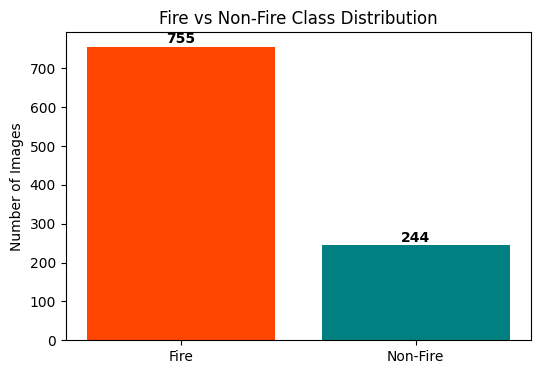

In [20]:
# Your exploration here

# Count files in each class directory
fire_dir = "fire-dataset/fire_dataset/fire_images"
non_fire_dir = "fire-dataset/fire_dataset/non_fire_images"

num_fire = len(os.listdir(fire_dir))
num_non_fire = len(os.listdir(non_fire_dir))
total_images = num_fire + num_non_fire

print("=== Dataset Distribution Summary ===")
print(f"Fire images: {num_fire} ({num_fire/total_images*100:.2f}%)")
print(f"Non-fire images: {num_non_fire} ({num_non_fire/total_images*100:.2f}%)")
print(f"Total images: {total_images}")

# Visualize the distribution
fig, ax = plt.subplots(figsize=(6, 4))
classes = ['Fire', 'Non-Fire']
counts = [num_fire, num_non_fire]
ax.bar(classes, counts, color=['orangered', 'teal'])
ax.set_ylabel('Number of Images')
ax.set_title('Fire vs Non-Fire Class Distribution')
for i, v in enumerate(counts):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*

About 75% of the images this dataset contains are images of fire and about 25% are images of non fire. Since the picture percentages are uneven, the data should be stratified when splitting.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [21]:
# Preprocess the data here
def preprocess_for_mobilenet(images, labels):
    # MobileNetV2 preprocess_input expects float values in range [-1, 1]
    return preprocess_input(images), labels

train_fire = train_raw_fire.map(preprocess_for_mobilenet)
val_fire = val_raw_fire.map(preprocess_for_mobilenet)
test_fire = test_raw_fire.map(preprocess_for_mobilenet)

In [22]:
# Build your model here

# Load pre-trained MobileNetV2 base model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze the base model weights
base_model.trainable = False

# Construct the model pipeline
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)  # keep base model in inference mode
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation='sigmoid')(x)  # Single unit for binary classification (fire/non-fire)

model = Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
# Compile the model using Binary Crossentropy
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 1D — Train and Evaluate

In [24]:
# Train your model here
history = model.fit(
    train_fire,
    validation_data=val_fire,
    epochs=10,
    verbose=1
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9143 - loss: 0.2221 - val_accuracy: 0.9568 - val_loss: 0.1586
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9729 - loss: 0.1061 - val_accuracy: 0.9784 - val_loss: 0.1023
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9800 - loss: 0.0777 - val_accuracy: 0.9568 - val_loss: 0.0808
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9886 - loss: 0.0637 - val_accuracy: 0.9712 - val_loss: 0.0702
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9914 - loss: 0.0541 - val_accuracy: 0.9856 - val_loss: 0.0547
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9929 - loss: 0.0479 - val_accuracy: 0.9640 - val_loss: 0.0745
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9929 - loss: 0.0428 - val_accuracy: 0.9712 - val_loss: 0.0772
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9943 - loss: 0.0390 - val_accuracy: 0.9784 - val_loss:

In [25]:
# Report validation and test accuracy here

val_loss, val_acc = model.evaluate(val_fire, verbose=0)
test_loss, test_acc = model.evaluate(test_fire, verbose=0)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

Validation Loss: 0.0548
Validation Accuracy: 97.12%
Test Loss: 0.0691
Test Accuracy: 96.88%


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

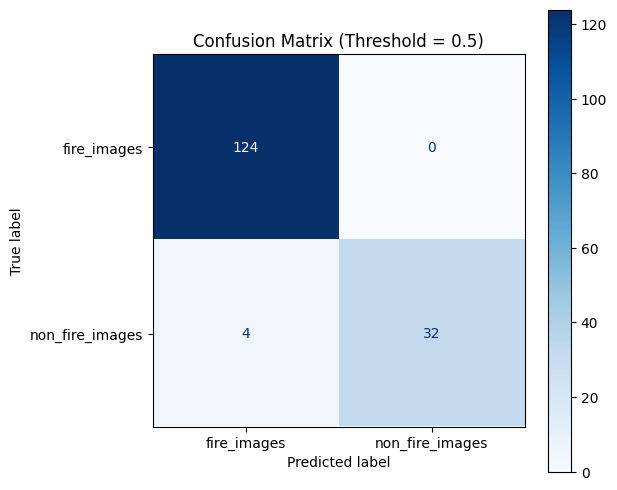

                 precision    recall  f1-score   support

    fire_images       0.97      1.00      0.98       124
non_fire_images       1.00      0.89      0.94        36

       accuracy                           0.97       160
      macro avg       0.98      0.94      0.96       160
   weighted avg       0.98      0.97      0.97       160



In [26]:
# Extract true labels and predictions from the test dataset
y_true = []
y_pred_probs = []

for images, labels in test_fire:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities to binary predictions using the default threshold of 0.5
y_pred = (y_pred_probs >= 0.5).astype(int)

# Generate and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_fire)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.show()

# Calculate recall and precision
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names_fire))

*Your answer:*


I think in this instance, a false negative would be more detrimental. If a fire is predicted but it ends up being a false alarm, people may be annoyed but no one's life would be in danger. However, if a real fire was missed and no alarm was raised, people's lives could be at stake.

---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [27]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

replace eurosat_data/EuroSAT_RGB/Forest/Forest_864.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace eurosat_data/EuroSAT_RGB/Forest/Forest_2917.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace eurosat_data/EuroSAT_RGB/Forest/Forest_2903.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [28]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


=== EuroSAT Dataset Distribution Summary ===
AnnualCrop: 3000 images (11.11%)
HerbaceousVegetation: 3000 images (11.11%)
Residential: 3000 images (11.11%)
Forest: 3000 images (11.11%)
SeaLake: 3000 images (11.11%)
PermanentCrop: 2500 images (9.26%)
Highway: 2500 images (9.26%)
Industrial: 2500 images (9.26%)
River: 2500 images (9.26%)
Pasture: 2000 images (7.41%)
Total images: 27000


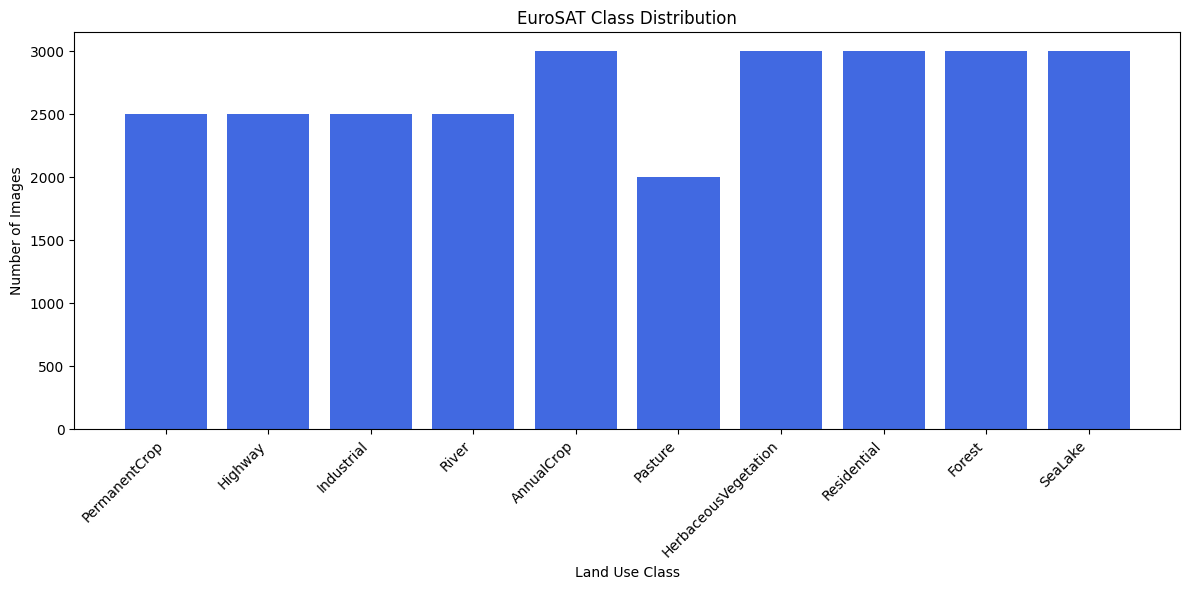

In [35]:
import os
import matplotlib.pyplot as plt

# Count the number of images in each class directory for EuroSAT
sat_classes = os.listdir(data_dir_sat)
class_counts = {}

for cls in sat_classes:
    cls_path = os.path.join(data_dir_sat, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

# Print a summary of the distribution
total_sat_images = sum(class_counts.values())
print("=== EuroSAT Dataset Distribution Summary ===")
for cls, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{cls}: {count} images ({count / total_sat_images * 100:.2f}%)")
print(f"Total images: {total_sat_images}")

# Plot the class distribution
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='royalblue')
plt.xlabel('Land Use Class')
plt.ylabel('Number of Images')
plt.title('EuroSAT Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [36]:
# Preprocess the satellite dataset using MobileNetV2 preprocessing
def preprocess_for_mobilenet_sat(images, labels):
    return preprocess_input(images), labels

train_sat = train_raw_sat.map(preprocess_for_mobilenet_sat)
val_sat = val_raw_sat.map(preprocess_for_mobilenet_sat)
test_sat = test_raw_sat.map(preprocess_for_mobilenet_sat)

print("EuroSAT data preprocessed successfully!")

EuroSAT data preprocessed successfully!


In [37]:
# Load pre-trained MobileNetV2 base model
base_model_sat = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze the base model weights
base_model_sat.trainable = False

# Construct the model pipeline for 10-class satellite land-use classification
inputs_sat = tf.keras.Input(shape=(224, 224, 3))
x_sat = base_model_sat(inputs_sat, training=False)
x_sat = GlobalAveragePooling2D()(x_sat)
outputs_sat = Dense(10, activation='softmax')(x_sat)

model_sat = Model(inputs_sat, outputs_sat)
model_sat.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
# Compile your model here
model_sat.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 2C — Train and Evaluate

In [39]:
# Train your model here
history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=5,
    verbose=1
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 945s 2s/step - accuracy: 0.8786 - loss: 0.3735 - val_accuracy: 0.9277 - val_loss: 0.2240
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1031s 2s/step - accuracy: 0.9343 - loss: 0.1952 - val_accuracy: 0.9408 - val_loss: 0.1906
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 941s 2s/step - accuracy: 0.9472 - loss: 0.1591 - val_accuracy: 0.9383 - val_loss: 0.1853
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 973s 2s/step - accuracy: 0.9550 - loss: 0.1380 - val_accuracy: 0.9428 - val_loss: 0.1781
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 970s 2s/step - accuracy: 0.9602 - loss: 0.1213 - val_accuracy: 0.9425 - val_loss: 0.1759


In [40]:
# Report validation and test accuracy here
val_loss_sat, val_acc_sat = model_sat.evaluate(val_sat, verbose=1)
test_loss_sat, test_acc_sat = model_sat.evaluate(test_sat, verbose=1)

print(f"EuroSAT Validation Loss: {val_loss_sat:.4f}")
print(f"EuroSAT Validation Accuracy: {val_acc_sat*100:.2f}%")
print(f"EuroSAT Test Loss: {test_loss_sat:.4f}")
print(f"EuroSAT Test Accuracy: {test_acc_sat*100:.2f}%")

127/127 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.9413 - loss: 0.1799
127/127 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9412 - loss: 0.1768
EuroSAT Validation Loss: 0.1799
EuroSAT Validation Accuracy: 94.13%
EuroSAT Test Loss: 0.1768
EuroSAT Test Accuracy: 94.12%


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

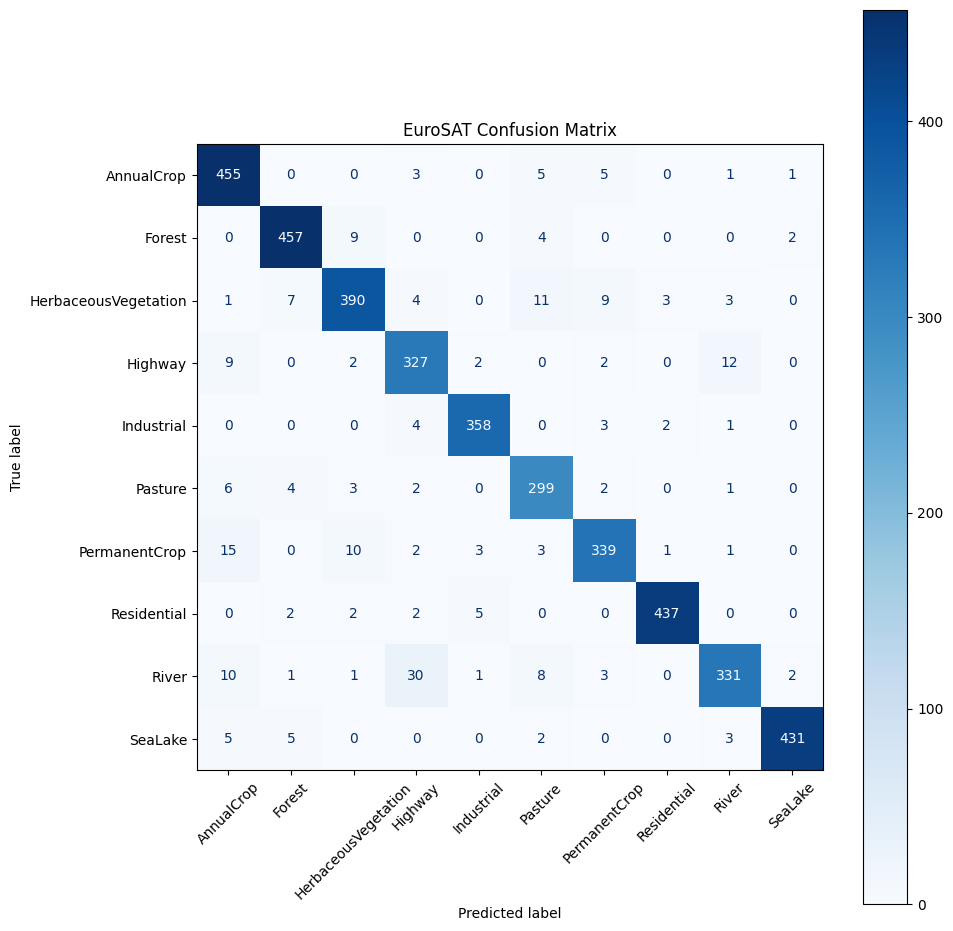

In [41]:
# Extract true labels and predictions from the EuroSAT test dataset
y_true_sat = []
y_pred_sat = []

for images, labels in test_sat:
    y_true_sat.extend(labels.numpy())
    preds = model_sat.predict(images, verbose=0)
    y_pred_sat.extend(np.argmax(preds, axis=1))

y_true_sat = np.array(y_true_sat)
y_pred_sat = np.array(y_pred_sat)

# Generate and plot confusion matrix
cm_sat = confusion_matrix(y_true_sat, y_pred_sat)
fig, ax = plt.subplots(figsize=(10, 10))
disp_sat = ConfusionMatrixDisplay(confusion_matrix=cm_sat, display_labels=class_names_sat)
disp_sat.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("EuroSAT Confusion Matrix")
plt.tight_layout()
plt.show()

The classes that get confused the most are river and highway. This does make sense because when looking at the images in the folder, the highways and rivers have somewhat similar shapes, and if the highway is in a rural area, they may have similar surrounding features (vegetation, dirt, etc). There is also some confusion between permanent crop and annual crop. When inspecting the images, the biggest differences between them is if the crop sqaures are green with plants or brown wuth dirt, so the confusion is understandable there as well.

---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |97.12% |94.13% |
| Test Accuracy |96.88% |94.12% |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

1. The fire dataset would be a better match for the original training of MobileNetv2. This is because most of the images in the fire dataset were taken from closer to the ground and have objects in them that either are or aren't on fire. The model can recognize these objects since they are a closer match to the original object pictures it was trained on and then use its knowledge of what fire is to predict if it's on fire or not. Most of the images in the EuroSAT data are from an aerial view, so the model has a harder time making predictions. This can be seen in the accuracy table, where the fire dataset had both higher validation accuracy and test accuracy.

2. For the fire dataset, I imagine if the model was trained on more fire images, it would be able to predict them easier. However, the fire images being taken from the same perspective as the images the model was trained on helps make up for the lack of fire training. If we were to adjust the model for the second dataset, it would be helpful to train it on more images from different perspectives and further views to help it better recognize patterns.

---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

1. The proportions of the data for the fire dataset were unbalanced; 75% of the images were of fire and only 25% were of non fire images. This means the data had to be stratified when splitting into training and testing splits so that that proportion would remain the same in each of the sets.

2. In the fire model, we are doing a binary classification (fire or no fire), so the activation function used is sigmoid and there is only 1 output neuron. For the EuroSAT model, there are 10 different classes, so the output layer needs to have 10 neurons and the softmax activation function is used so that all of the outputs add up to 1.

3. Both the quality of the pretrained model and how well it matches your task matter for how useful a model can be. As noted before, the types of images in the EuroSAT data didn't match the images MobileNet was trained on as well, so there was a slight dip in accuracy and an increase in loss compared to the fire dataset (0.176 vs 0.069).


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.